# Predictive Modelling: Sleep Quality

This standalone notebook compares five classification algorithms for predicting
`sleep_quality_category`. Every candidate uses the same features, preprocessing,
SMOTENC resampling, inner hyperparameter search, nested stratified cross-validation,
and untouched holdout set.

> This is synthetic observational data. Prediction does not imply causation or clinical validity.

## 1. Setup

Required packages: `pandas numpy matplotlib seaborn scikit-learn imbalanced-learn joblib nbformat nbclient`.

In [1]:
from pathlib import Path
import json, warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier, VotingClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, classification_report,
                             confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
ROOT = Path.cwd()
DATA_PATH = ROOT / 'sleep_doomscrolling_habits.csv'
CHART_DIR = ROOT / 'assets' / 'charts'
MODEL_DIR = ROOT / 'models'
CHART_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
COLORS = {'bg':'#081120','panel':'#101D33','ink':'#EAF2FF','muted':'#91A4C8',
          'cyan':'#5EE7F7','blue':'#6889FF','violet':'#A78BFA','pink':'#F08CCF',
          'gold':'#F3C96B','mint':'#68D5B1','grid':'#263A5D'}
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.facecolor':COLORS['bg'],'axes.facecolor':COLORS['panel'],
                     'axes.edgecolor':COLORS['grid'],'axes.labelcolor':COLORS['ink'],
                     'xtick.color':COLORS['muted'],'ytick.color':COLORS['muted'],
                     'text.color':COLORS['ink'],'grid.color':COLORS['grid']})

def save_chart(fig, filename):
    fig.savefig(CHART_DIR / filename, dpi=190, bbox_inches='tight', facecolor=COLORS['bg'])
    plt.show(); plt.close(fig)

df = pd.read_csv(DATA_PATH)
df['doomscroll_load_minutes'] = (
    df['doomscroll_sessions_per_night'] * df['avg_doomscroll_session_minutes']
)
print(f'Loaded {len(df):,} respondents and {df.shape[1]} columns')

Loaded 1,000 respondents and 31 columns


## 2. Leakage controls and preprocessing

`respondent_id` is an identifier and `sleep_quality_score` is an outcome-adjacent
measurement, so both are excluded. The holdout is split before any fitting. Numeric
imputation, categorical imputation and encoding, SMOTENC, scaling, and the classifier
are contained in one pipeline. Consequently, validation and holdout rows never
influence imputation, synthetic examples, or tuning.

In [2]:
target = 'sleep_quality_category'
excluded = {'respondent_id', target, 'sleep_quality_score'}
feature_cols = [c for c in df.columns if c not in excluded]
X, y = df[feature_cols].copy(), df[target].copy()
categorical_cols = X.select_dtypes(include=['object','string','category']).columns.tolist()
numeric_cols = [c for c in X.columns if c not in categorical_cols]

preprocess = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), numeric_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
    ]), categorical_cols)
])
categorical_indices = list(range(len(numeric_cols), len(numeric_cols) + len(categorical_cols)))
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=.25, stratify=y, random_state=RANDOM_STATE
)
display(y.value_counts().rename('count').to_frame().assign(percent=lambda d:100*d['count']/len(y)))
print(f'Training rows: {len(X_train)} | Untouched holdout rows: {len(X_holdout)}')

,count,percent
sleep_quality_category,,
Good,340,34.0
Poor,330,33.0
Fair,330,33.0


Training rows: 750 | Untouched holdout rows: 250


## 3. Candidate algorithms and search spaces

The comparison covers a linear model, two tree ensembles, a nonlinear kernel model,
and gradient boosting. Search spaces are deliberately compact for reproducibility.
Balanced accuracy is the selection metric because it weights each outcome class equally.

In [3]:
candidates = {
    'Logistic Regression': (
        LogisticRegression(max_iter=2500, class_weight='balanced', random_state=RANDOM_STATE),
        {'model__C':[.01,.05,.1,.5,1,2,5,10], 'model__solver':['lbfgs','liblinear']}
    ),
    'Random Forest': (
        RandomForestClassifier(class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=1),
        {'model__n_estimators':[200,350,500], 'model__max_depth':[None,8,14,20],
         'model__min_samples_leaf':[1,2,4,7], 'model__max_features':['sqrt','log2',.7]}
    ),
    'Extra Trees': (
        ExtraTreesClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1),
        {'model__n_estimators':[200,350,500], 'model__max_depth':[None,8,14,20],
         'model__min_samples_leaf':[1,2,4,7], 'model__max_features':['sqrt','log2',.7]}
    ),
    'SVM (RBF)': (
        SVC(class_weight='balanced', probability=True, random_state=RANDOM_STATE),
        {'model__C':[.1,.5,1,2,5,10], 'model__gamma':['scale','auto',.001,.01,.1]}
    ),
    'Histogram Gradient Boosting': (
        HistGradientBoostingClassifier(class_weight='balanced', random_state=RANDOM_STATE),
        {'model__learning_rate':[.03,.05,.1,.15], 'model__max_iter':[100,200,300],
         'model__max_leaf_nodes':[15,31,63], 'model__l2_regularization':[0,.1,1,5]}
    ),
}

def make_pipeline(estimator):
    return ImbPipeline([
        ('prep', clone(preprocess)),
        ('smote', SMOTENC(categorical_features=categorical_indices,
                          random_state=RANDOM_STATE, k_neighbors=5)),
        ('scale', StandardScaler()),
        ('model', estimator)
    ])

print('Models:', ', '.join(candidates))

Models: Logistic Regression, Random Forest, Extra Trees, SVM (RBF), Histogram Gradient Boosting


## 4. Nested cross-validation and tuning

For every outer fold, randomized search runs only on that fold's training partition.
The selected pipeline is then scored on the unseen outer validation partition. This
makes the reported cross-validation score a genuine estimate of the complete tuning
procedure rather than the best score observed during tuning.

In [4]:
outer_cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
results, fitted_searches, fold_details = [], {}, []

for model_index, (name, (estimator, params)) in enumerate(candidates.items()):
    fold_scores = []
    for fold, (fit_idx, valid_idx) in enumerate(outer_cv.split(X_train, y_train), start=1):
        inner_cv = StratifiedKFold(3, shuffle=True,
                                  random_state=RANDOM_STATE + 100*model_index + fold)
        search = RandomizedSearchCV(
            make_pipeline(clone(estimator)), params, n_iter=10,
            scoring='balanced_accuracy', cv=inner_cv, refit=True,
            random_state=RANDOM_STATE + fold, n_jobs=-1
        )
        search.fit(X_train.iloc[fit_idx], y_train.iloc[fit_idx])
        score = balanced_accuracy_score(
            y_train.iloc[valid_idx], search.predict(X_train.iloc[valid_idx])
        )
        fold_scores.append(score)
        fold_details.append({'model':name, 'fold':fold,
                             'balanced_accuracy':score,
                             'best_inner_score':search.best_score_})

    final_search = RandomizedSearchCV(
        make_pipeline(clone(estimator)), params, n_iter=16,
        scoring='balanced_accuracy',
        cv=StratifiedKFold(4,shuffle=True,random_state=RANDOM_STATE),
        refit=True, random_state=RANDOM_STATE, n_jobs=-1
    )
    final_search.fit(X_train, y_train)
    fitted_searches[name] = final_search
    holdout_pred = final_search.predict(X_holdout)
    results.append({
        'model':name,
        'nested_cv_balanced_accuracy':np.mean(fold_scores),
        'nested_cv_sd':np.std(fold_scores),
        'holdout_accuracy':accuracy_score(y_holdout,holdout_pred),
        'holdout_balanced_accuracy':balanced_accuracy_score(y_holdout,holdout_pred),
        'holdout_macro_f1':f1_score(y_holdout,holdout_pred,average='macro')
    })
    print(f'{name}: nested CV={np.mean(fold_scores):.3f} +/- {np.std(fold_scores):.3f}')

comparison = pd.DataFrame(results).sort_values('nested_cv_balanced_accuracy',ascending=False)
winner_name = comparison.iloc[0]['model']
winner = fitted_searches[winner_name].best_estimator_
display(comparison)
print(f'Selected model: {winner_name}')

Logistic Regression: nested CV=0.583 +/- 0.052


Random Forest: nested CV=0.603 +/- 0.046


Extra Trees: nested CV=0.593 +/- 0.049


SVM (RBF): nested CV=0.597 +/- 0.042


Histogram Gradient Boosting: nested CV=0.564 +/- 0.026


,model,nested_cv_balanced_accuracy,nested_cv_sd,holdout_accuracy,holdout_balanced_accuracy,holdout_macro_f1
1,Random Forest,0.602851,0.046195,0.556,0.555155,0.548094
3,SVM (RBF),0.597312,0.042111,0.568,0.567207,0.559295
2,Extra Trees,0.593257,0.048577,0.584,0.583562,0.574948
0,Logistic Regression,0.582507,0.051600,0.600,0.599626,0.593306
4,Histogram Gradient Boosting,0.563536,0.025875,0.568,0.567774,0.565581


Selected model: Random Forest


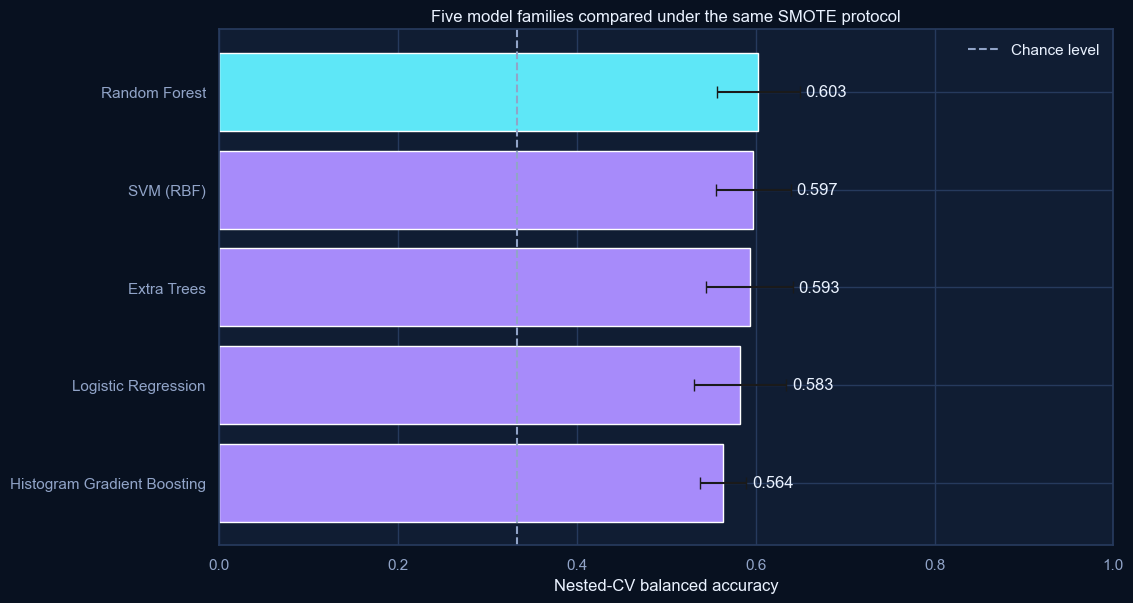

In [5]:
fig, ax = plt.subplots(figsize=(11.5,6.2))
plot_data = comparison.sort_values('nested_cv_balanced_accuracy')
bars = ax.barh(plot_data.model, plot_data.nested_cv_balanced_accuracy,
               xerr=plot_data.nested_cv_sd,
               color=[COLORS['cyan'] if m == winner_name else COLORS['violet'] for m in plot_data.model],
               capsize=4)
ax.axvline(1/3,color=COLORS['muted'],ls='--',label='Chance level')
ax.set_xlim(0,1); ax.set_xlabel('Nested-CV balanced accuracy')
ax.set_title('Five model families compared under the same SMOTE protocol')
ax.legend(frameon=False)
ax.bar_label(bars,labels=[f'{v:.3f}' for v in plot_data.nested_cv_balanced_accuracy],padding=4,color=COLORS['ink'])
fig.tight_layout(); save_chart(fig,'13_model_comparison.png')

## 5. Untouched holdout evaluation

The holdout was not used for model selection or hyperparameter tuning. It provides one
final diagnostic of how each fitted model transfers to completely unseen respondents.

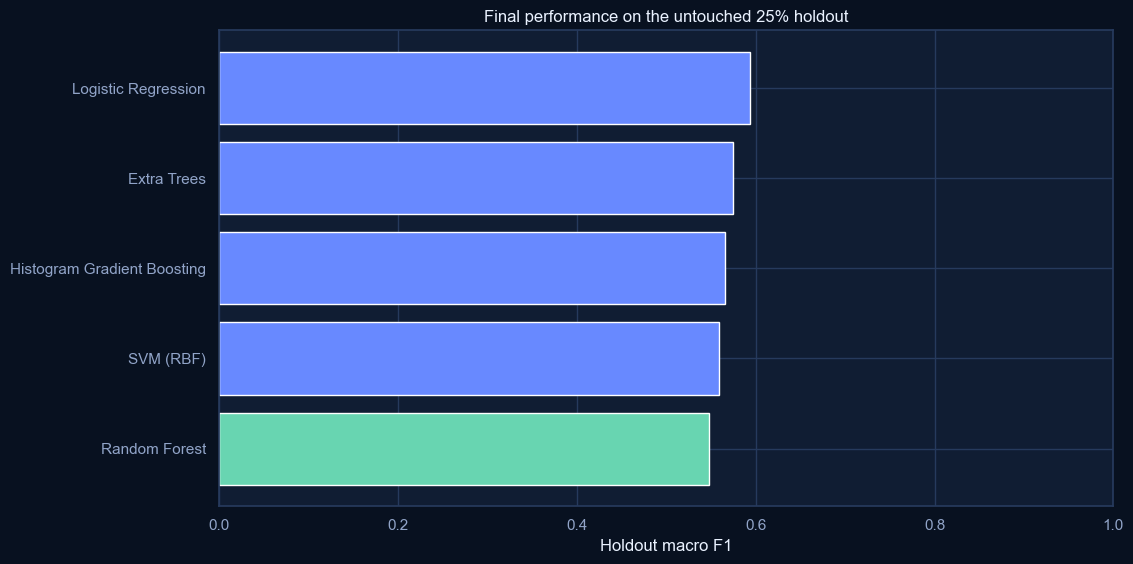

,precision,recall,f1-score,support
Fair,0.426471,0.349398,0.384106,83.000
Good,0.584158,0.694118,0.634409,85.000
Poor,0.629630,0.621951,0.625767,82.000
accuracy,0.556000,0.556000,0.556000,0.556
macro avg,0.546753,0.555155,0.548094,250.000
weighted avg,0.546721,0.556000,0.548474,250.000


,Predicted Fair,Predicted Good,Predicted Poor
Actual Fair,29,29,25
Actual Good,21,59,5
Actual Poor,18,13,51


In [6]:
fig, ax = plt.subplots(figsize=(11.5,5.8))
holdout_plot = comparison.sort_values('holdout_macro_f1')
ax.barh(holdout_plot.model, holdout_plot.holdout_macro_f1,
        color=[COLORS['mint'] if m == winner_name else COLORS['blue'] for m in holdout_plot.model])
ax.set_xlim(0,1); ax.set_xlabel('Holdout macro F1')
ax.set_title('Final performance on the untouched 25% holdout')
fig.tight_layout(); save_chart(fig,'14_model_holdout.png')

winner_pred = winner.predict(X_holdout)
labels = list(winner.classes_)
report = pd.DataFrame(classification_report(y_holdout,winner_pred,output_dict=True)).T
matrix = pd.DataFrame(confusion_matrix(y_holdout,winner_pred,labels=labels),
                      index=[f'Actual {x}' for x in labels],
                      columns=[f'Predicted {x}' for x in labels])
display(report); display(matrix)

## 6. Best-model interpretation

Permutation importance is calculated directly on the untouched holdout using balanced
accuracy. It measures the predictive contribution of each original input while retaining
the full preprocessing and SMOTE pipeline. It is not a causal effect estimate.

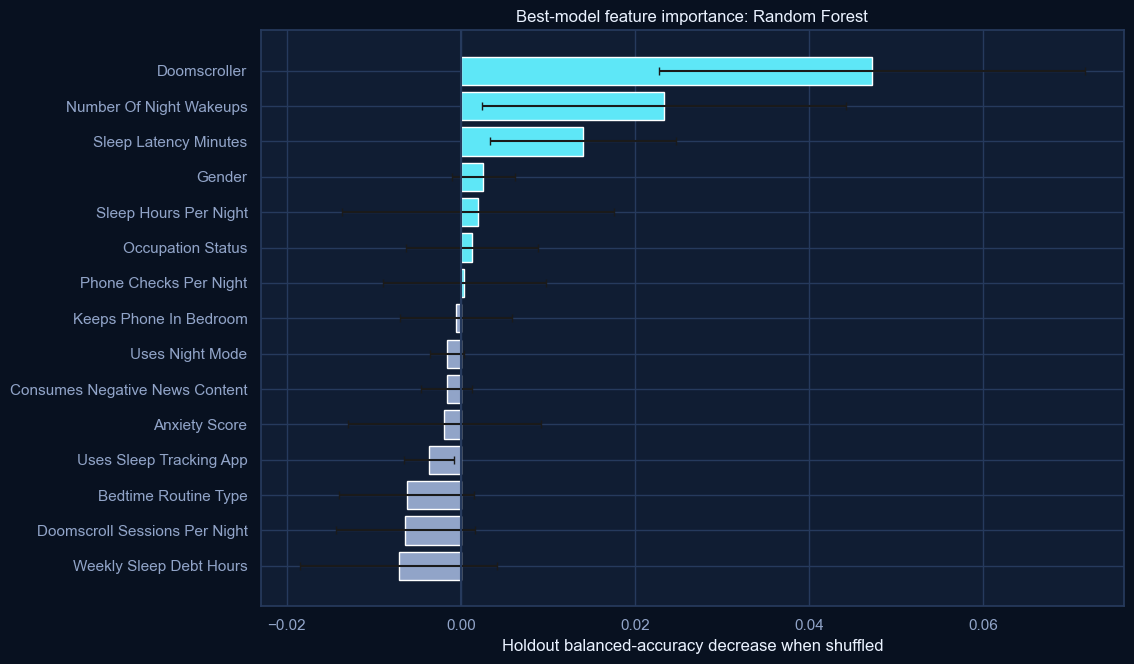

,feature,importance,sd
26,doomscroller,0.047223,0.024482
7,number_of_night_wakeups,0.023303,0.020909
6,sleep_latency_minutes,0.014026,0.010667
17,gender,0.002594,0.003652
5,sleep_hours_per_night,0.001956,0.015665
18,occupation_status,0.001263,0.007608
13,phone_checks_per_night,0.000421,0.009399
23,keeps_phone_in_bedroom,-0.000527,0.006444
22,uses_night_mode,-0.001569,0.001921
24,consumes_negative_news_content,-0.001624,0.002955


In [7]:
perm = permutation_importance(
    winner, X_holdout, y_holdout, n_repeats=20,
    random_state=RANDOM_STATE, scoring='balanced_accuracy', n_jobs=-1
)
importance = pd.DataFrame({'feature':feature_cols,
                           'importance':perm.importances_mean,
                           'sd':perm.importances_std}).sort_values('importance',ascending=False)
top = importance.head(15).sort_values('importance')
fig, ax = plt.subplots(figsize=(11.5,6.8))
ax.barh(top.feature.str.replace('_',' ').str.title(),top.importance,xerr=top.sd,
        color=[COLORS['cyan'] if v > 0 else COLORS['muted'] for v in top.importance],capsize=3)
ax.axvline(0,color=COLORS['grid']); ax.set_xlabel('Holdout balanced-accuracy decrease when shuffled')
ax.set_title(f'Best-model feature importance: {winner_name}')
fig.tight_layout(); save_chart(fig,'14_feature_importance.png')
display(importance.head(15))

## 7. Actionable poor-sleep risk model

Three-class prediction asks the model to distinguish `Good`, `Fair`, and `Poor`, even
though the boundary between Good and Fair is noisy in this synthetic survey. For a more
actionable decision problem, this section predicts **Poor sleep vs. not Poor sleep**.
The original three-class benchmark remains above for transparency; this is a different,
explicitly binary target and its accuracy must not be compared as if the tasks were equal.

Extra Trees, Random Forest, RBF SVM, and a soft-voting ensemble are compared. SMOTENC is
also tested on Extra Trees. It slightly lowers raw accuracy but improves balanced accuracy
and minority-class F1, so the SMOTE version is selected for risk screening.

,model,accuracy,balanced_accuracy,roc_auc,f1,balanced_accuracy_sd
4,Extra Trees + SMOTE,0.793,0.767865,0.849367,0.688564,0.033611
1,Extra Trees,0.802,0.759973,0.852013,0.679097,0.028425
2,RBF SVM,0.781,0.757372,0.841180,0.674113,0.027727
3,Soft Voting,0.802,0.753053,0.849073,0.669269,0.025602
0,Random Forest,0.797,0.745477,0.842469,0.658351,0.020654


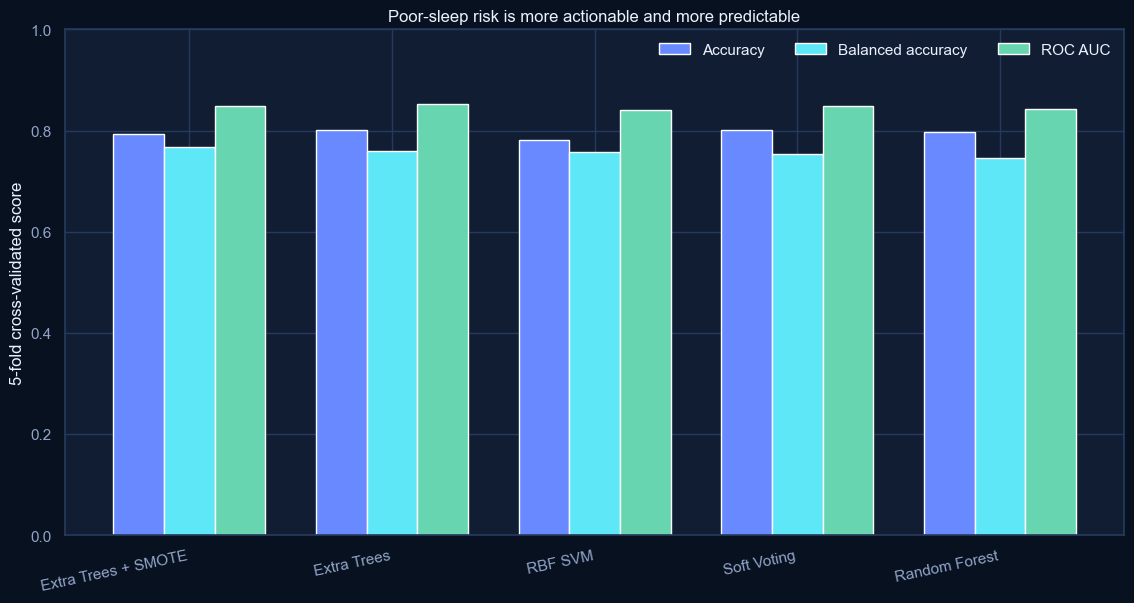

Binary holdout: {'accuracy': 0.788, 'balanced_accuracy': np.float64(0.7655652550321045), 'roc_auc': np.float64(0.8473414616550032), 'f1': np.float64(0.6863905325443787)}


In [8]:
y_binary = y.eq('Poor').astype(int)
rf_binary = RandomForestClassifier(
    n_estimators=700,max_features='log2',min_samples_leaf=2,
    class_weight='balanced',random_state=RANDOM_STATE,n_jobs=1)
et_binary = ExtraTreesClassifier(
    n_estimators=700,max_features='sqrt',min_samples_leaf=2,
    class_weight='balanced',random_state=RANDOM_STATE,n_jobs=1)
svm_binary = SVC(C=1,gamma='scale',class_weight='balanced',probability=True,random_state=RANDOM_STATE)
vote_binary = VotingClassifier(
    [('rf',rf_binary),('et',et_binary),('svm',svm_binary)],
    voting='soft',weights=[3,1,2],n_jobs=1)
binary_models = {
    'Random Forest': ImbPipeline([('prep',clone(preprocess)),('scale',StandardScaler()),('model',rf_binary)]),
    'Extra Trees': ImbPipeline([('prep',clone(preprocess)),('scale',StandardScaler()),('model',et_binary)]),
    'RBF SVM': ImbPipeline([('prep',clone(preprocess)),('scale',StandardScaler()),('model',svm_binary)]),
    'Soft Voting': ImbPipeline([('prep',clone(preprocess)),('scale',StandardScaler()),('model',vote_binary)]),
    'Extra Trees + SMOTE': ImbPipeline([
        ('prep',clone(preprocess)),
        ('smote',SMOTENC(categorical_features=categorical_indices,random_state=RANDOM_STATE)),
        ('scale',StandardScaler()),('model',clone(et_binary))
    ])
}
binary_rows=[]
binary_cv=StratifiedKFold(5,shuffle=True,random_state=RANDOM_STATE)
for name,binary_model in binary_models.items():
    scores=cross_validate(binary_model,X,y_binary,cv=binary_cv,
                          scoring=['accuracy','balanced_accuracy','roc_auc','f1'],n_jobs=-1)
    binary_rows.append({
        'model':name,'accuracy':scores['test_accuracy'].mean(),
        'balanced_accuracy':scores['test_balanced_accuracy'].mean(),
        'roc_auc':scores['test_roc_auc'].mean(),'f1':scores['test_f1'].mean(),
        'balanced_accuracy_sd':scores['test_balanced_accuracy'].std()
    })
binary_comparison=pd.DataFrame(binary_rows).sort_values('balanced_accuracy',ascending=False)
display(binary_comparison)

fig,ax=plt.subplots(figsize=(11.5,6.2))
x=np.arange(len(binary_comparison)); width=.25
ax.bar(x-width,binary_comparison.accuracy,width,label='Accuracy',color=COLORS['blue'])
ax.bar(x,binary_comparison.balanced_accuracy,width,label='Balanced accuracy',color=COLORS['cyan'])
ax.bar(x+width,binary_comparison.roc_auc,width,label='ROC AUC',color=COLORS['mint'])
ax.set_xticks(x,binary_comparison.model,rotation=12,ha='right'); ax.set_ylim(0,1)
ax.set_ylabel('5-fold cross-validated score'); ax.set_title('Poor-sleep risk is more actionable and more predictable')
ax.legend(frameon=False,ncol=3); fig.tight_layout(); save_chart(fig,'15_binary_risk_model.png')

X_binary_train,X_binary_holdout,y_binary_train,y_binary_holdout=train_test_split(
    X,y_binary,test_size=.25,stratify=y_binary,random_state=RANDOM_STATE)
binary_winner=clone(binary_models['Extra Trees + SMOTE']).fit(X_binary_train,y_binary_train)
binary_pred=binary_winner.predict(X_binary_holdout)
binary_prob=binary_winner.predict_proba(X_binary_holdout)[:,1]
binary_holdout={
    'accuracy':accuracy_score(y_binary_holdout,binary_pred),
    'balanced_accuracy':balanced_accuracy_score(y_binary_holdout,binary_pred),
    'roc_auc':roc_auc_score(y_binary_holdout,binary_prob),
    'f1':f1_score(y_binary_holdout,binary_pred)
}
print('Binary holdout:',binary_holdout)

## 8. Export reproducible modelling artifacts

In [9]:
comparison.to_csv(ROOT/'multi_model_comparison.csv',index=False)
pd.DataFrame(fold_details).to_csv(ROOT/'nested_cv_fold_results.csv',index=False)
report.to_csv(ROOT/'best_model_classification_report.csv')
matrix.to_csv(ROOT/'best_model_confusion_matrix.csv')
importance.to_csv(ROOT/'multi_model_feature_importance.csv',index=False)
binary_comparison.to_csv(ROOT/'binary_risk_model_comparison.csv',index=False)
joblib.dump(winner,MODEL_DIR/'best_sleep_quality_model.joblib')
joblib.dump(binary_winner,MODEL_DIR/'poor_sleep_risk_model.joblib')

best_params={name:search.best_params_ for name,search in fitted_searches.items()}
(ROOT/'model_best_params.json').write_text(json.dumps(best_params,indent=2),encoding='utf-8')
summary={
    'selected_model':winner_name,
    'nested_cv_balanced_accuracy':float(comparison.iloc[0].nested_cv_balanced_accuracy),
    'nested_cv_sd':float(comparison.iloc[0].nested_cv_sd),
    'holdout_balanced_accuracy':float(comparison.iloc[0].holdout_balanced_accuracy),
    'holdout_macro_f1':float(comparison.iloc[0].holdout_macro_f1),
    'models_compared':comparison.model.tolist(),
    'best_params':best_params[winner_name],
    'top_predictors':importance.head(10).feature.tolist(),
    'binary_selected_model':'Extra Trees + SMOTE',
    'binary_cv_accuracy':float(binary_comparison.loc[binary_comparison.model.eq('Extra Trees + SMOTE'),'accuracy'].iloc[0]),
    'binary_cv_balanced_accuracy':float(binary_comparison.loc[binary_comparison.model.eq('Extra Trees + SMOTE'),'balanced_accuracy'].iloc[0]),
    'binary_cv_roc_auc':float(binary_comparison.loc[binary_comparison.model.eq('Extra Trees + SMOTE'),'roc_auc'].iloc[0]),
    'binary_holdout':binary_holdout
}
(ROOT/'modeling_summary.json').write_text(json.dumps(summary,indent=2),encoding='utf-8')
print(json.dumps(summary,indent=2))

{
  "selected_model": "Random Forest",
  "nested_cv_balanced_accuracy": 0.6028512738428705,
  "nested_cv_sd": 0.04619466076684738,
  "holdout_balanced_accuracy": 0.5551554856441548,
  "holdout_macro_f1": 0.5480938111936942,
  "models_compared": [
    "Random Forest",
    "SVM (RBF)",
    "Extra Trees",
    "Logistic Regression",
    "Histogram Gradient Boosting"
  ],
  "best_params": {
    "model__n_estimators": 200,
    "model__min_samples_leaf": 1,
    "model__max_features": "log2",
    "model__max_depth": null
  },
  "top_predictors": [
    "doomscroller",
    "number_of_night_wakeups",
    "sleep_latency_minutes",
    "gender",
    "sleep_hours_per_night",
    "occupation_status",
    "phone_checks_per_night",
    "keeps_phone_in_bedroom",
    "uses_night_mode",
    "consumes_negative_news_content"
  ],
  "binary_selected_model": "Extra Trees + SMOTE",
  "binary_cv_accuracy": 0.7929999999999999,
  "binary_cv_balanced_accuracy": 0.7678652193577566,
  "binary_cv_roc_auc": 0.849366802

## Conclusion

Model selection is based on nested cross-validation, not the most favorable holdout
result. Differences between close models should be treated cautiously because this is a
modest, apparently synthetic dataset. SMOTE is retained as requested and applied safely,
but it cannot manufacture additional real-world information.